<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [ ]:
import sqlite3

from IPython.core.history import sqlite3_found
!pip install pandas

In [ ]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [1]:
# Step 1: Download the dataset
# !wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the data
df = pd.read_csv("survey_data.csv")

# Display the first few rows to understand the structure of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



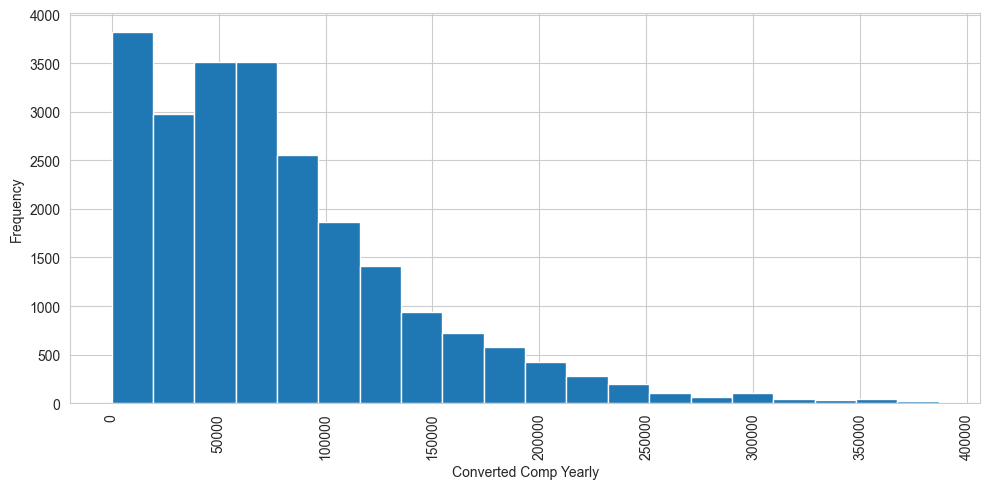

In [5]:
## Write your code here
df_comp = df['ConvertedCompYearly'].quantile(0.99)
df_comp = df[df['ConvertedCompYearly']<df_comp]
df_comp['ConvertedCompYearly'].plot(kind = 'hist', bins = 20, figsize = (10,5))
plt.xlabel('Converted Comp Yearly')
plt.ylabel('Frequency')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



In [10]:
df['Age'].unique()

<StringArray>
['Under 18 years old',    '35-44 years old',    '45-54 years old',
    '18-24 years old',    '25-34 years old',    '55-64 years old',
  'Prefer not to say',  '65 years or older']
Length: 8, dtype: str

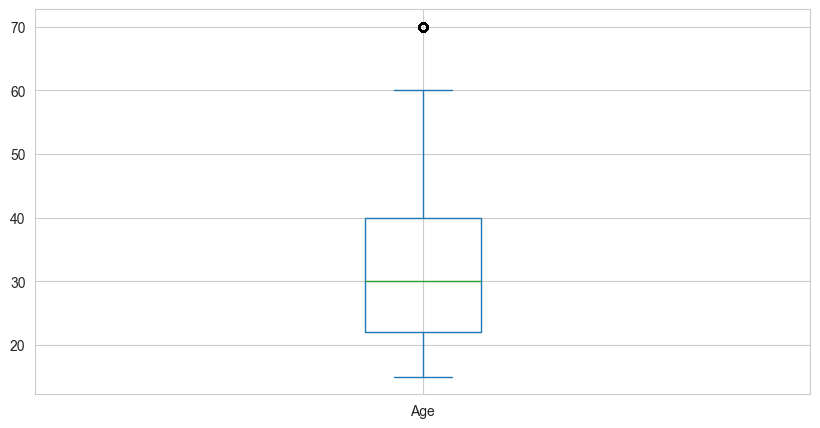

In [15]:
## Write your code here
age_map = {'Under 18 years old': 15,    '35-44 years old': 40,    '45-54 years old': 50,
    '18-24 years old': 22,    '25-34 years old': 30,    '55-64 years old': 60,
  'Prefer not to say': None,  '65 years or older': 70}
df_AgeNumeric = df['Age'].map(age_map)
df_AgeNumeric.plot(kind = 'box', figsize = (10,5))
plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



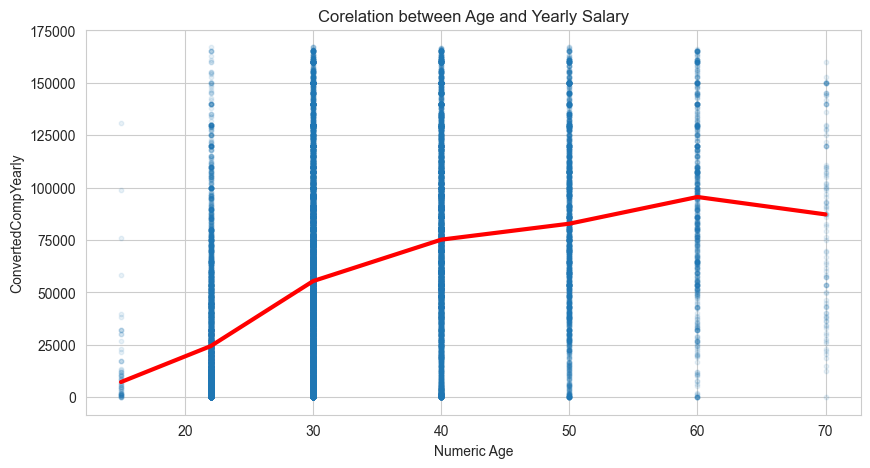

In [21]:
## Write your code here
df['AgeNumeric'] = df['Age'].map(age_map)
df_comp = df['ConvertedCompYearly'].quantile(0.90)
df_comp = df[df['ConvertedCompYearly']<df_comp]
df_scatter = df_comp[['AgeNumeric','ConvertedCompYearly']].dropna()
df_scatter.plot(kind = 'scatter', x = 'AgeNumeric', y = 'ConvertedCompYearly', figsize = (10,5), alpha = 0.1, s = 10)
plt.xlabel('Numeric Age')
plt.ylabel('ConvertedCompYearly')
plt.title('Corelation between Age and Yearly Salary')
# 1. Calculate the median salary for each age group
median_line = df_scatter.groupby('AgeNumeric')['ConvertedCompYearly'].median()

# 2. Plot it on top of your scatter dots
plt.plot(median_line.index, median_line.values, color='red', linewidth=3, label='Median Trend')

plt.tight_layout
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


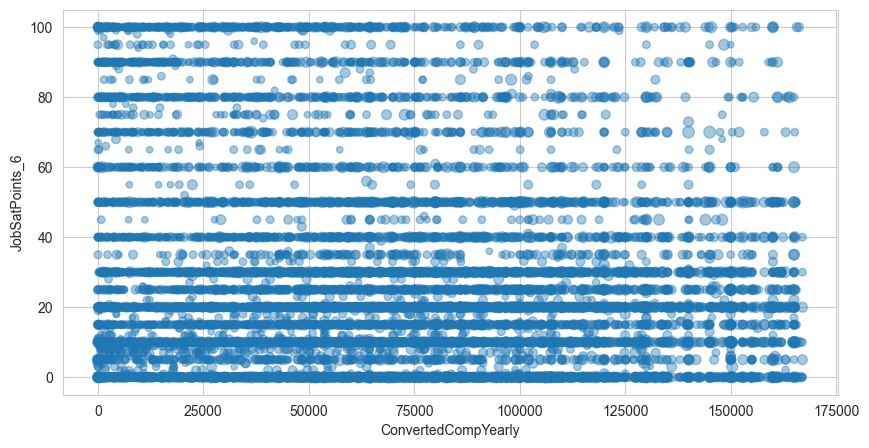

In [36]:
## Write your code here
df['AgeNumeric'] = df['Age'].map(age_map)
df_comp = df['ConvertedCompYearly'].quantile(0.90)
df_comp = df[df['ConvertedCompYearly']<df_comp]
df_clean = df_comp[['ConvertedCompYearly', 'JobSatPoints_6', 'AgeNumeric']].dropna()

df_clean.plot(kind = 'scatter', x = 'ConvertedCompYearly', y = 'JobSatPoints_6', figsize = (10,5), s=df_clean['AgeNumeric'], alpha = 0.4)
plt.show()

<Axes: xlabel='ConvertedCompYearly', ylabel='JobSatPoints_6'>

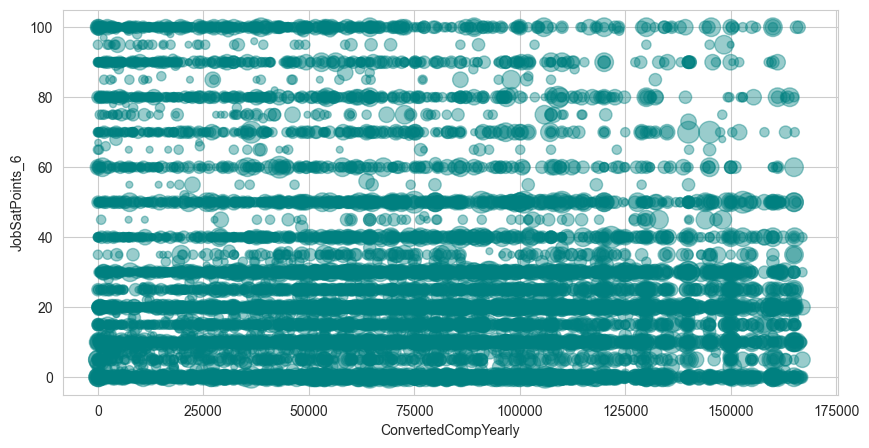

In [37]:
# Square the age to make the difference in area aggressive and visible
df_clean.plot(kind='scatter', x='ConvertedCompYearly', y='JobSatPoints_6',
              s=(df_clean['AgeNumeric']**2) / 20, # Squaring makes 60 much larger than 20
              alpha=0.4, figsize=(10,5), color='teal')


### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



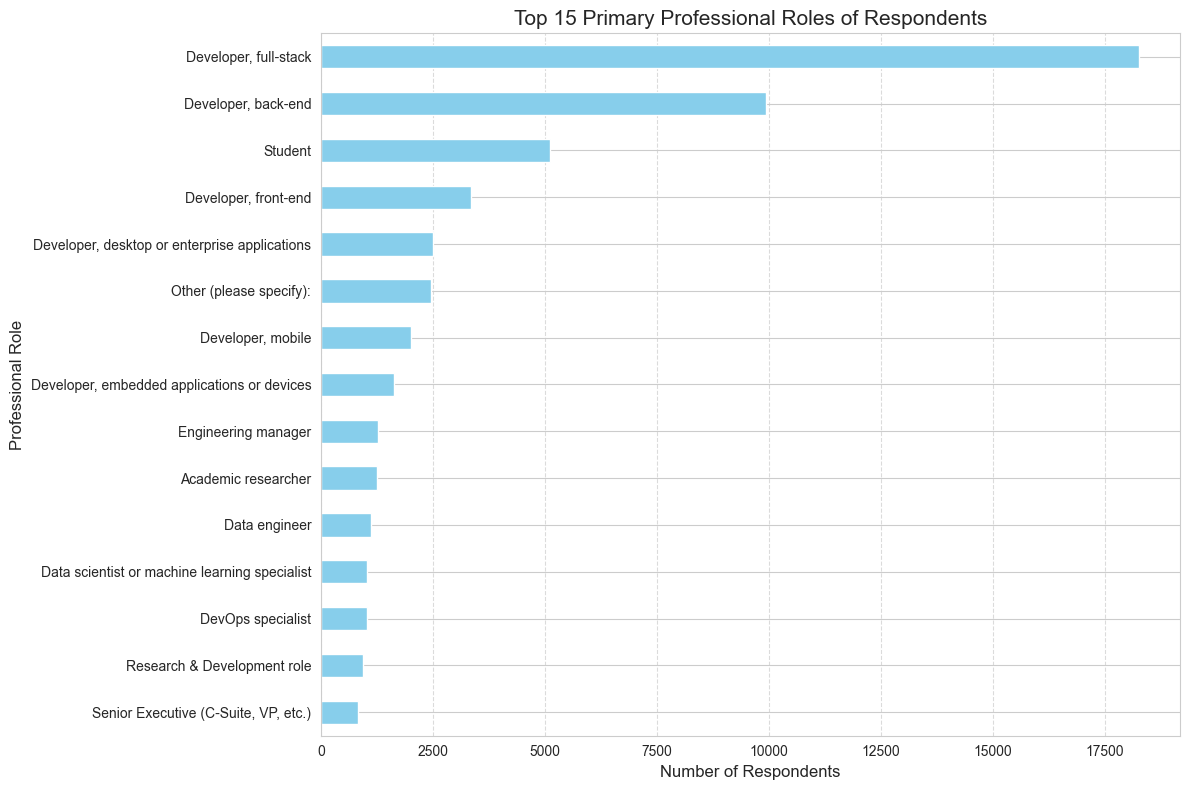

In [38]:
## Write your code here
import matplotlib.pyplot as plt

# 1. Clean and Explode the roles
df_roles = df.dropna(subset=['DevType']).copy()
df_roles['Role'] = df_roles['DevType'].str.split(';')
df_roles_exp = df_roles.explode('Role')

# 2. Clean whitespace and get top 15 roles
df_roles_exp['Role'] = df_roles_exp['Role'].str.strip()
top_roles = df_roles_exp['Role'].value_counts().head(15)

# 3. Visualize as a Horizontal Bar Chart
top_roles.sort_values().plot(kind='barh', figsize=(12, 8), color='skyblue')

plt.title('Top 15 Primary Professional Roles of Respondents', fontsize=15)
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Professional Role', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



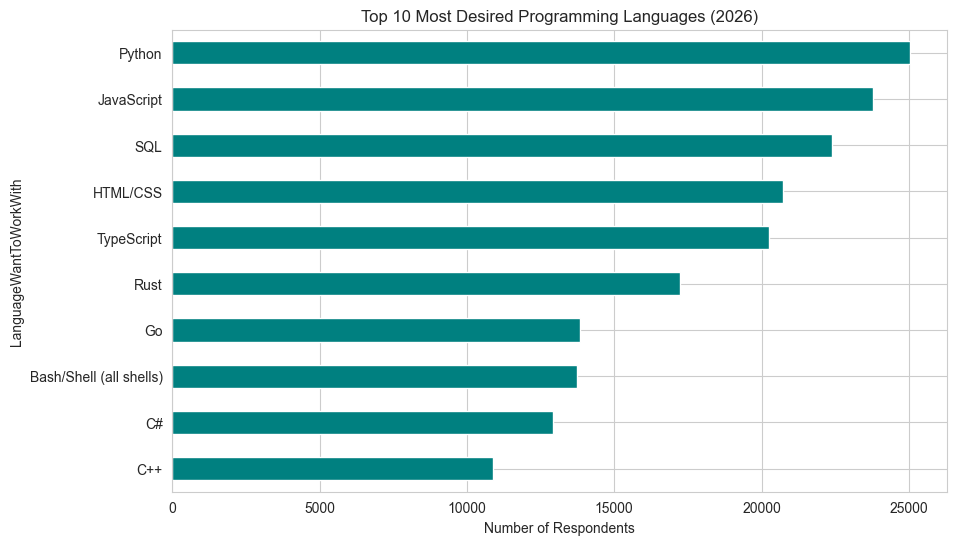

In [39]:
## Write your code here
# 1. Split the semi-colon strings into lists and expand into individual rows
df_desired = df['LanguageWantToWorkWith'].str.split(';').explode().str.strip()

# 2. Count the occurrences and grab the top 10
top_desired_langs = df_desired.value_counts().head(10)

# 3. Visualize for professional focus
top_desired_langs.sort_values().plot(kind='barh', color='teal', figsize=(10, 6))
plt.title('Top 10 Most Desired Programming Languages (2026)')
plt.xlabel('Number of Respondents')
plt.show()



##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


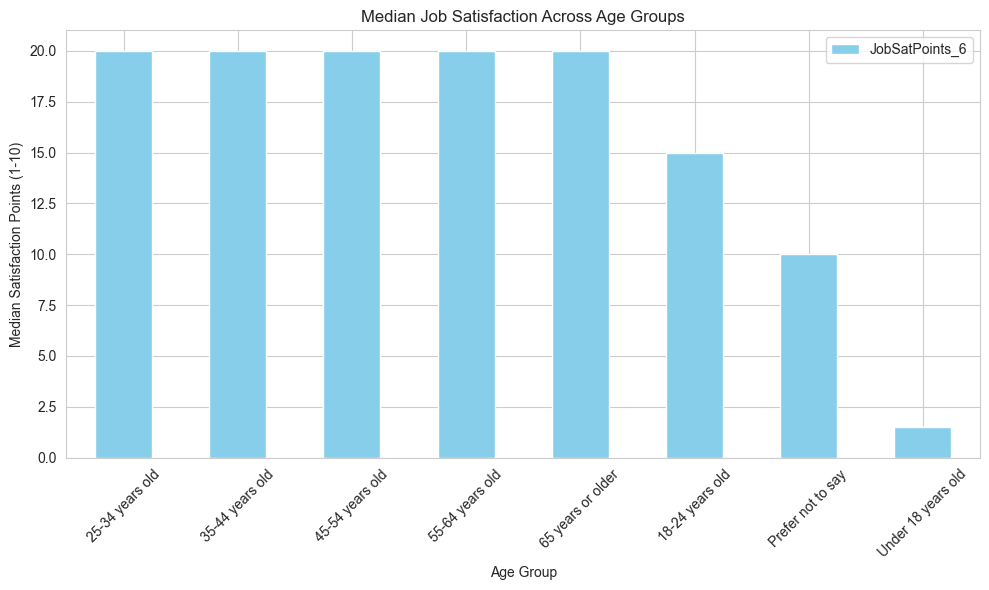

In [44]:
## Write your code here
import sqlite3
conn = sqlite3.connect(':memory:')
df.to_sql('survey', conn, index=False, if_exists='replace')
query = "SELECT Age, JobSatPoints_6 FROM survey WHERE JobSatPoints_6 IS NOT NULL"
df_sat = pd.read_sql(query, conn)
df_grouped = df_sat.groupby('Age')['JobSatPoints_6'].median().reset_index()
# Setting Age as index for the plot
df_grouped.set_index('Age', inplace=True)
df_grouped.sort_values('JobSatPoints_6', ascending=False).plot(kind='bar', stacked=True, figsize=(10, 6), color='skyblue')

plt.title('Median Job Satisfaction Across Age Groups')
plt.ylabel('Median Satisfaction Points (1-10)')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



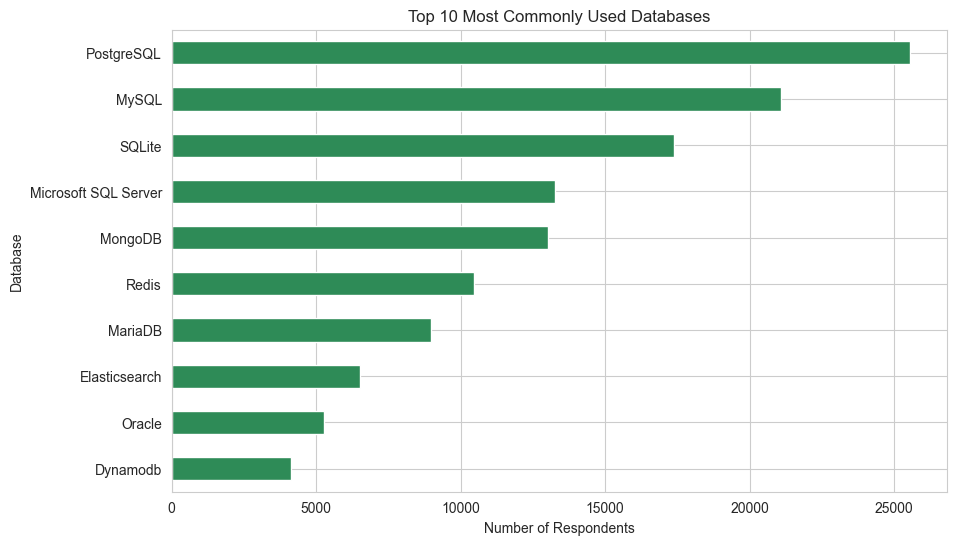

In [45]:
## Write your code here
# 1. Split the semicolon-separated strings into lists and expand into individual rows
df_databases = df['DatabaseHaveWorkedWith'].str.split(';').explode()

# 2. Count the occurrences of each database
database_counts = df_databases.value_counts()

# 3. Visualize the top 10 most common databases using a horizontal bar chart
database_counts.head(10).sort_values().plot(kind='barh', color='seagreen', figsize=(10, 6))

plt.title('Top 10 Most Commonly Used Databases')
plt.xlabel('Number of Respondents')
plt.ylabel('Database')
plt.show()


### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



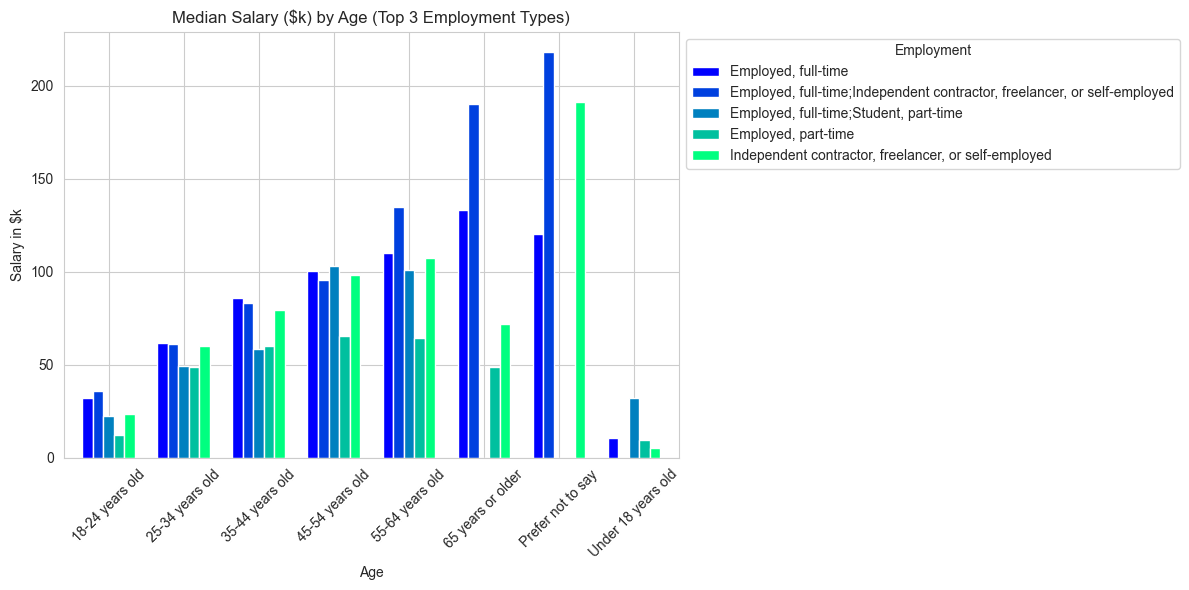

In [48]:
# 1. Filter for the 3 most common Employment types to reduce "clutter"
top_3_emp = df_comp['Employment'].value_counts().nlargest(5).index
df_reduced = df_comp[df_comp['Employment'].isin(top_3_emp)]

# 2. Pivot the data (Age as X-axis, Top 3 Employment as bars)
# We divide by 1000 to show 'Salary in $k' (e.g., 80 instead of 80000)
df_pivot = df_reduced.groupby(['Age', 'Employment'])['ConvertedCompYearly'].median().unstack()
df_pivot = df_pivot / 1000

# 3. Plot with increased spacing (width) and better colors
ax = df_pivot.plot(kind='bar', figsize=(12, 6), width=0.7, colormap='winter')

plt.title('Median Salary ($k) by Age (Top 3 Employment Types)')
plt.ylabel('Salary in $k')
plt.xticks(rotation=45)
plt.legend(title='Employment', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()


##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



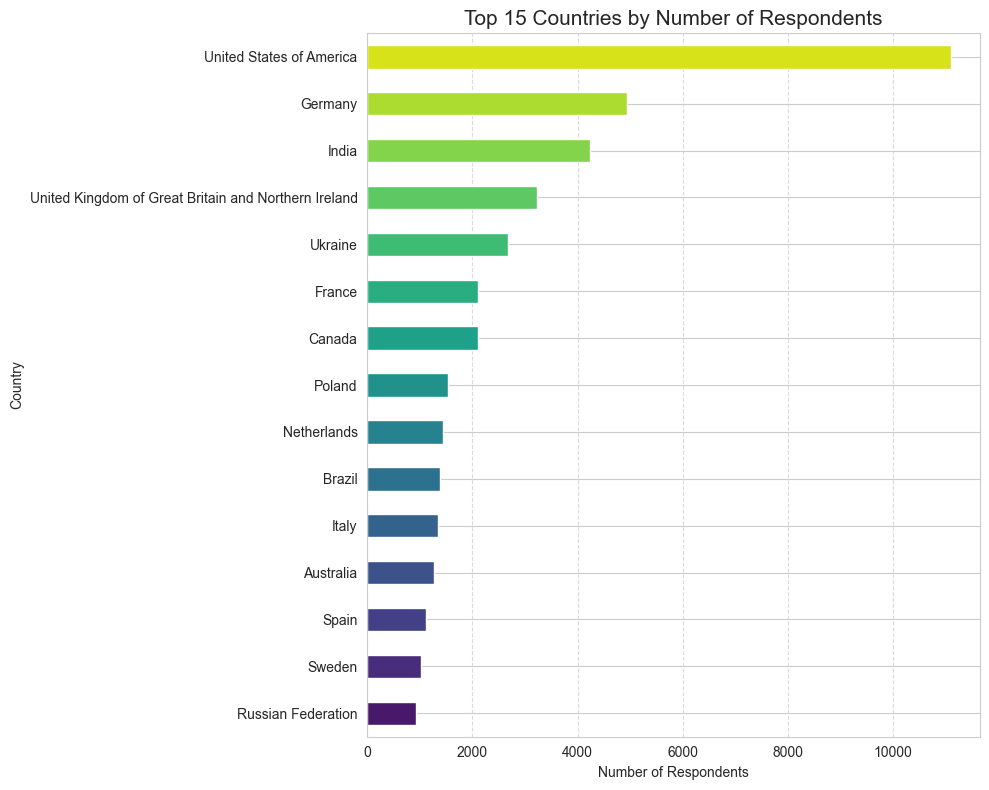

In [49]:
## Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Count respondents per country and take the Top 15
top_countries = df['Country'].value_counts().head(15)

# 2. Plotting as a horizontal bar chart
plt.figure(figsize=(10, 8))
top_countries.sort_values().plot(kind='barh', color=sns.color_palette('viridis', 15))

# 3. Formatting
plt.title('Top 15 Countries by Number of Respondents', fontsize=15)
plt.xlabel('Number of Respondents')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
